# Classical Baselines: ETS and SARIMA

Both models are fast and share the same conceptual framing — decompose the series into trend, seasonality, and error. Running them in a single notebook makes the side-by-side comparison direct.

**Outline**
1. Load train/test data
2. Build month-dummy exogenous matrix
3. ETS — multiplicative vs additive seasonality comparison
4. SARIMA — auto_arima with monthly exog, residual diagnostics
5. Metrics: RMSE, MAE, MAPE
6. Side-by-side forecast plot and export

---

## Step 0: Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import os
import copy
import warnings
warnings.filterwarnings('ignore')

from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.graphics.tsaplots import plot_acf
from sklearn.metrics import mean_absolute_error
import pmdarima

## Step 1: Load Data

In [2]:
train = pd.read_csv('../data/daily_train.csv', index_col='datetime', parse_dates=True)
test  = pd.read_csv('../data/daily_test.csv',  index_col='datetime', parse_dates=True)

train_series = train['power']
test_series  = test['power']

print(f"Train: {train_series.index.min().date()} → {train_series.index.max().date()} ({len(train_series)} obs)")
print(f"Test:  {test_series.index.min().date()}  → {test_series.index.max().date()} ({len(test_series)} obs)")

Train: 2006-12-16 → 2009-11-30 (1081 obs)
Test:  2009-12-01  → 2010-11-26 (361 obs)


## Step 2: Month Dummy Exogenous Matrix

Month dummies are the practical way to inject annual seasonality into SARIMA on daily data. The alternative — `m=365` in `auto_arima` — is computationally infeasible: the seasonal search space over a 365-lag grid makes the fit run for hours and typically produces unstable estimates. The approach here uses `m=7` for the ARIMA seasonal component (weekly cycles) and month dummies as exogenous regressors to capture the annual pattern.

All 12 months are kept (no `drop_first`) because SARIMA has no intercept by default; dropping one column would leave the baseline month unrepresented.

In [3]:
def build_month_dummies(index):
    dummies = pd.get_dummies(index.month, prefix='m', drop_first=False)
    dummies.index = index
    return dummies.astype(float)

train_exog = build_month_dummies(train_series.index)
test_exog  = build_month_dummies(test_series.index)

# align columns in case test set doesn't cover every month
test_exog = test_exog.reindex(columns=train_exog.columns, fill_value=0.0)

train_exog.head(3)

,m_1,m_2,m_3,m_4,m_5,m_6,m_7,m_8,m_9,m_10,m_11,m_12
datetime,,,,,,,,,,,,
2006-12-16,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
2006-12-17,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
2006-12-18,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0


## Step 3: ETS

### 3.1 Multiplicative vs Additive Seasonality

Multiplicative seasonality scales the seasonal component proportionally to the level — appropriate when winter variance is larger *relative to* the series level, not just additively larger. Energy consumption has this property: high-usage winter months show wider swings than low-usage summer months. Fit both and compare AIC.

In [4]:
ets_mul = ExponentialSmoothing(
    train_series,
    trend='add',
    seasonal='mul',
    seasonal_periods=7
).fit(optimized=True)

ets_add = ExponentialSmoothing(
    train_series,
    trend='add',
    seasonal='add',
    seasonal_periods=7
).fit(optimized=True)

print(f"{'Model':<28} {'AIC':>10}")
print("-" * 39)
print(f"{'ETS(A,A,A) — additive seas':<28} {ets_add.aic:>10.2f}")
print(f"{'ETS(A,A,M) — multiplicative seas':<28} {ets_mul.aic:>10.2f}")
print(f"\nΔAIC (add − mul): {ets_add.aic - ets_mul.aic:+.2f}")
print("\nUsing multiplicative for downstream forecasting.")

C:\Users\brody\anaconda3\envs\energy-forecast\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
C:\Users\brody\anaconda3\envs\energy-forecast\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


Model                               AIC
---------------------------------------
ETS(A,A,A) — additive seas     -2558.27
ETS(A,A,M) — multiplicative seas   -2580.91

ΔAIC (add − mul): +22.64

Using multiplicative for downstream forecasting.


### 3.2 ETS Walk-Forward Forecast

The test set is split into non-overlapping 30-day folds. At each fold, ETS is refit on all data observed so far — the original training series plus every actual test observation from prior folds. This matches how the model would be used in production: new data arrives, the model is updated, a fresh 30-day forecast is issued.

In [5]:
FOLD_SIZE   = 30
N_FOLDS     = 12
fold_starts = list(range(0, N_FOLDS * FOLD_SIZE, FOLD_SIZE))

ets_preds_list = []
ets_context    = train_series.copy()

for i, start in enumerate(fold_starts):
    end      = min(start + FOLD_SIZE, len(test_series))
    fold_len = end - start

    m = ExponentialSmoothing(
        ets_context, trend='add', seasonal='mul', seasonal_periods=7
    ).fit(optimized=True)

    preds = m.forecast(fold_len)
    preds.index = test_series.index[start:end]
    ets_preds_list.append(preds)

    ets_context = pd.concat([ets_context, test_series.iloc[start:end]])
    print(f"  ETS fold {i+1}/{len(fold_starts)}: days {start+1}–{end}")

ets_forecast = pd.concat(ets_preds_list)
print(f"\nCompleted {len(fold_starts)} folds covering {len(ets_forecast)} test days")

  ETS fold 1/12: days 1–30


C:\Users\brody\anaconda3\envs\energy-forecast\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
C:\Users\brody\anaconda3\envs\energy-forecast\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


  ETS fold 2/12: days 31–60


  ETS fold 3/12: days 61–90
  ETS fold 4/12: days 91–120


C:\Users\brody\anaconda3\envs\energy-forecast\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
C:\Users\brody\anaconda3\envs\energy-forecast\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
C:\Users\brody\anaconda3\envs\energy-forecast\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


...

C:\Users\brody\anaconda3\envs\energy-forecast\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
C:\Users\brody\anaconda3\envs\energy-forecast\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


  ETS fold 9/12: days 241–270
  ETS fold 10/12: days 271–300


C:\Users\brody\anaconda3\envs\energy-forecast\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
C:\Users\brody\anaconda3\envs\energy-forecast\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


  ETS fold 11/12: days 301–330
  ETS fold 12/12: days 331–360

Completed 12 folds covering 360 test days


C:\Users\brody\anaconda3\envs\energy-forecast\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


## Step 4: SARIMA

### 4.1 Model Selection via auto_arima

In [6]:
sarima_model = pmdarima.auto_arima(
    train_series,
    X=train_exog.values,
    seasonal=True,
    m=7,              # weekly seasonal component
    d=None,           # ADF-selected integration order
    D=None,
    stepwise=True,
    information_criterion='aic',
    error_action='ignore',
    suppress_warnings=True,
    trace=True,
)

print(sarima_model.summary())

Performing stepwise search to minimize aic


 ARIMA(2,0,2)(1,0,1)[7] intercept   : AIC=453.948, Time=1.92 sec


 ARIMA(0,0,0)(0,0,0)[7] intercept   : AIC=766.587, Time=0.23 sec


 ARIMA(1,0,0)(1,0,0)[7] intercept   : AIC=560.606, Time=0.62 sec


 ARIMA(0,0,1)(0,0,1)[7] intercept   : AIC=577.548, Time=0.60 sec


...

 ARIMA(4,0,2)(1,0,2)[7]             : AIC=441.794, Time=3.72 sec


 ARIMA(3,0,0)(1,0,2)[7]             : AIC=446.750, Time=3.12 sec


 ARIMA(5,0,0)(1,0,2)[7]             : AIC=442.567, Time=3.30 sec


 ARIMA(5,0,2)(1,0,2)[7]             : AIC=447.456, Time=3.85 sec


 ARIMA(4,0,1)(1,0,2)[7] intercept   : AIC=445.728, Time=3.22 sec

Best model:  ARIMA(4,0,1)(1,0,2)[7]          
Total fit time: 153.883 seconds
                                       SARIMAX Results                                        
Dep. Variable:                                      y   No. Observations:                 1081
Model:             SARIMAX(4, 0, 1)x(1, 0, [1, 2], 7)   Log Likelihood                -198.714
Date:                                Mon, 08 Jun 2026   AIC                            439.427
Time:                                        00:35:26   BIC                            544.126
Sample:                                    12-16-2006   HQIC                           479.069
                                         - 11-30-2009                                         
Covariance Type:                                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
-----------------

### 4.2 Do Month Dummies Add Signal?

Refit auto_arima without exogenous regressors and compare AIC. A meaningful delta (typically > 10) confirms the month dummies are capturing annual variance that the ARIMA terms alone cannot.

In [7]:
sarima_no_exog = pmdarima.auto_arima(
    train_series,
    seasonal=True,
    m=7,
    d=None,
    D=None,
    stepwise=True,
    information_criterion='aic',
    error_action='ignore',
    suppress_warnings=True,
    trace=False,
)

aic_with    = sarima_model.aic()
aic_without = sarima_no_exog.aic()
delta       = aic_without - aic_with

print(f"{'Model':<35} {'AIC':>10}")
print("-" * 46)
print(f"{'SARIMA + month dummies':<35} {aic_with:>10.2f}")
print(f"{'SARIMA (no exog)':<35} {aic_without:>10.2f}")
print(f"\nΔAIC (no exog − with dummies): {delta:+.2f}")
print()
if delta > 10:
    print("Month dummies provide meaningful signal — keeping them.")
elif delta > 2:
    print("Month dummies provide modest improvement — worth keeping but not decisive.")
else:
    print("Month dummies add little signal — the ARIMA terms may already account for annual structure.")

Model                                      AIC
----------------------------------------------
SARIMA + month dummies                  439.43
SARIMA (no exog)                        463.30

ΔAIC (no exog − with dummies): +23.88

Month dummies provide meaningful signal — keeping them.


### 4.3 Residual Diagnostics

The standard 4-panel diagnostics check for normality and remaining autocorrelation. The annual ACF check below is the key honest-accounting step: if structure remains at lag ~365, the model has not captured the full seasonal pattern and month dummies alone were insufficient.

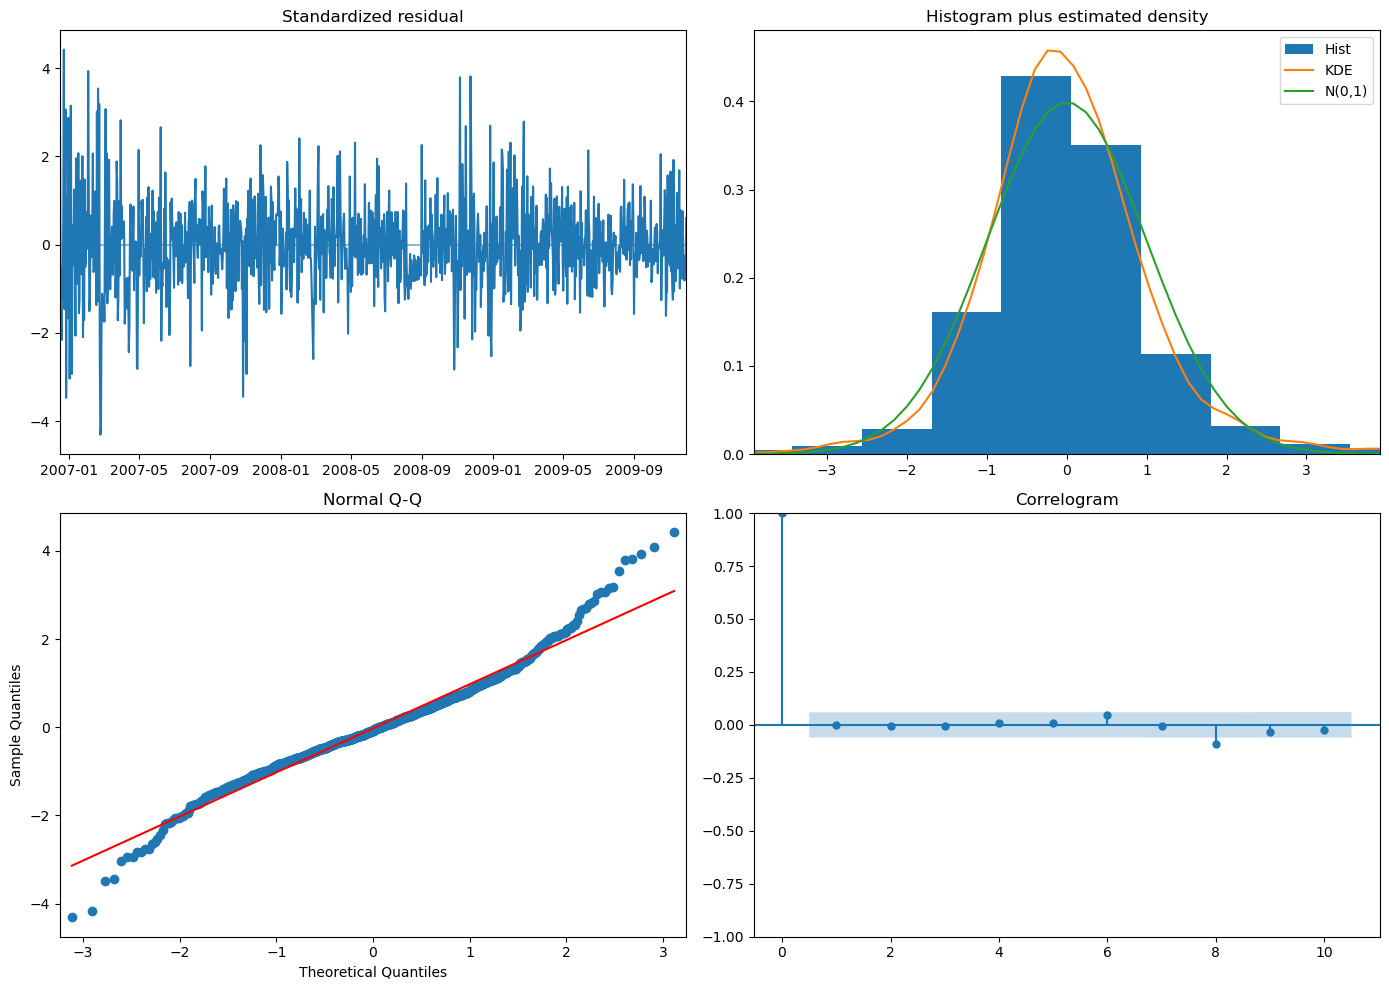

In [8]:
sarima_model.plot_diagnostics(figsize=(14, 10))
plt.tight_layout()
plt.show()

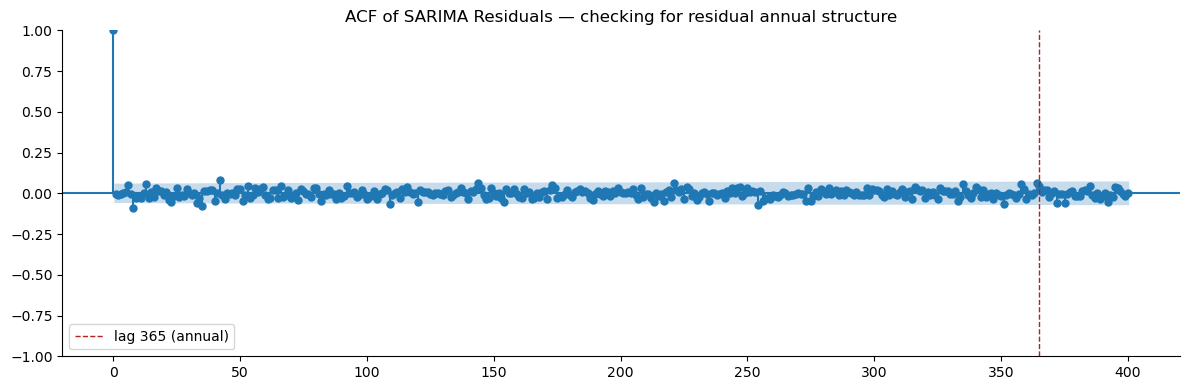

In [9]:
resid = pd.Series(sarima_model.resid(), index=train_series.index)

fig, ax = plt.subplots(figsize=(12, 4))
plot_acf(resid, lags=min(400, len(resid) - 1), ax=ax, alpha=0.05)
ax.axvline(x=365, color='firebrick', linestyle='--', linewidth=1.0, label='lag 365 (annual)')
ax.legend()
ax.set_title('ACF of SARIMA Residuals — checking for residual annual structure')
sns.despine()
plt.tight_layout()
plt.show()

**Residual notes** *(fill in after running)*

- If the ACF shows significant spikes near lag 365: the month dummies captured the average monthly level but not intra-annual variance — Fourier terms or a longer training window may help.
- If weekly lags (7, 14, 21…) still show spikes: `m=7` seasonal order selected by auto_arima is underfitting short-cycle patterns.
- Ljung-Box p-values below 0.05 in the diagnostics panel indicate autocorrelation in residuals — the model order should be revisited.

### 4.4 SARIMA Walk-Forward Forecast

SARIMA uses pmdarima's `.update()` to incorporate each fold's actual observations into the model state before predicting the next fold. This is more efficient than full refitting — the ARIMA parameters are fixed, only the internal state (the filter history) is updated — while still giving the model access to the most recent observations at each step.

In [10]:
sarima_rolling    = copy.deepcopy(sarima_model)
sarima_preds_list = []
sarima_ci_list    = []

for i, start in enumerate(fold_starts):
    end       = min(start + FOLD_SIZE, len(test_series))
    fold_exog = test_exog.iloc[start:end]

    preds, conf = sarima_rolling.predict(
        n_periods=end - start,
        X=fold_exog.values,
        return_conf_int=True,
    )
    sarima_preds_list.append(pd.Series(preds, index=test_series.index[start:end]))
    sarima_ci_list.append(pd.DataFrame(conf, index=test_series.index[start:end], columns=['lower', 'upper']))

    sarima_rolling.update(test_series.iloc[start:end].values, X=fold_exog.values)
    print(f"  SARIMA fold {i+1}/{len(fold_starts)}: days {start+1}–{end}")

sarima_forecast = pd.concat(sarima_preds_list)
conf_int_df     = pd.concat(sarima_ci_list)
print(f"\nCompleted {len(fold_starts)} folds covering {len(sarima_forecast)} test days")

  SARIMA fold 1/12: days 1–30


  SARIMA fold 2/12: days 31–60


  SARIMA fold 3/12: days 61–90


  SARIMA fold 4/12: days 91–120


  SARIMA fold 5/12: days 121–150


...

  SARIMA fold 8/12: days 211–240


  SARIMA fold 9/12: days 241–270


  SARIMA fold 10/12: days 271–300


  SARIMA fold 11/12: days 301–330


  SARIMA fold 12/12: days 331–360

Completed 12 folds covering 360 test days


## Step 5: Metrics

**Note on model symmetry:** ETS uses weekly seasonality only (`m=7`) with no mechanism to model annual structure. SARIMA uses the same weekly seasonal component but adds month dummy exogenous regressors to capture the strong annual pattern identified in the EDA. This is an intentional design difference — SARIMA's richer specification partly explains its performance advantage and should be considered when interpreting the gap between the two models.

In [11]:
def rmse(y_true, y_pred):
    return np.sqrt(np.mean((np.array(y_true) - np.array(y_pred)) ** 2))

def mape(y_true, y_pred):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

fold_rows = []
for i, start in enumerate(fold_starts):
    end = min(start + FOLD_SIZE, len(test_series))
    idx = test_series.index[start:end]
    act = test_series.loc[idx]
    fold_rows.append({
        'Fold':        i + 1,
        'ETS RMSE':    rmse(act, ets_forecast.loc[idx]),
        'ETS MAE':     mean_absolute_error(act, ets_forecast.loc[idx]),
        'ETS MAPE':    mape(act, ets_forecast.loc[idx]),
        'SARIMA RMSE': rmse(act, sarima_forecast.loc[idx]),
        'SARIMA MAE':  mean_absolute_error(act, sarima_forecast.loc[idx]),
        'SARIMA MAPE': mape(act, sarima_forecast.loc[idx]),
    })

fold_df = pd.DataFrame(fold_rows).set_index('Fold').round(4)
display(fold_df)

metrics = pd.DataFrame({
    'RMSE': [fold_df['ETS RMSE'].mean(),    fold_df['SARIMA RMSE'].mean()],
    'MAE':  [fold_df['ETS MAE'].mean(),     fold_df['SARIMA MAE'].mean()],
    'MAPE': [fold_df['ETS MAPE'].mean(),    fold_df['SARIMA MAPE'].mean()],
}, index=['ETS', 'SARIMA']).round(4)

print(f"\nMean across {len(fold_starts)} folds:")
print(metrics.to_string())
metrics.to_csv('../outputs/classical_metrics.csv')
print("\nSaved → ../outputs/classical_metrics.csv")

,ETS RMSE,ETS MAE,ETS MAPE,SARIMA RMSE,SARIMA MAE,SARIMA MAPE
Fold,,,,,,
1,0.3112,0.2486,18.1935,0.3000,0.2230,19.0228
2,0.2711,0.2039,16.0921,0.2604,0.2030,15.1131
3,0.4647,0.3599,34.5441,0.3546,0.2841,22.1594
4,0.3306,0.2689,30.5344,0.3223,0.2095,27.9449
5,0.2405,0.1893,21.4898,0.1819,0.1453,15.1839
6,0.3462,0.2928,24.8601,0.2323,0.1672,13.6739
7,0.1837,0.1440,16.8578,0.1762,0.1444,15.2845
8,0.1871,0.1563,22.7185,0.1707,0.1376,18.5811
9,0.2681,0.2242,47.5533,0.2631,0.2187,46.6263



Mean across 12 folds:
          RMSE     MAE     MAPE
ETS     0.2996  0.2428  25.2930
SARIMA  0.2574  0.1956  21.2892

Saved → ../outputs/classical_metrics.csv


In [12]:
leaderboard = metrics.sort_values('RMSE')
leaderboard.to_csv('../outputs/leaderboard.csv')
print('Saved → ../outputs/leaderboard.csv')

display(
    leaderboard.style
    .format({'RMSE': '{:.4f}', 'MAE': '{:.4f}', 'MAPE': '{:.2f}%'})
    .background_gradient(cmap='RdYlGn_r', subset=['RMSE', 'MAE', 'MAPE'])
    .set_caption('Model Leaderboard — sorted by RMSE (lower is better)')
)

Saved → ../outputs/leaderboard.csv


,RMSE,MAE,MAPE
SARIMA,0.2574,0.1956,21.29%
ETS,0.2996,0.2428,25.29%


## Step 6: Forecast Plot

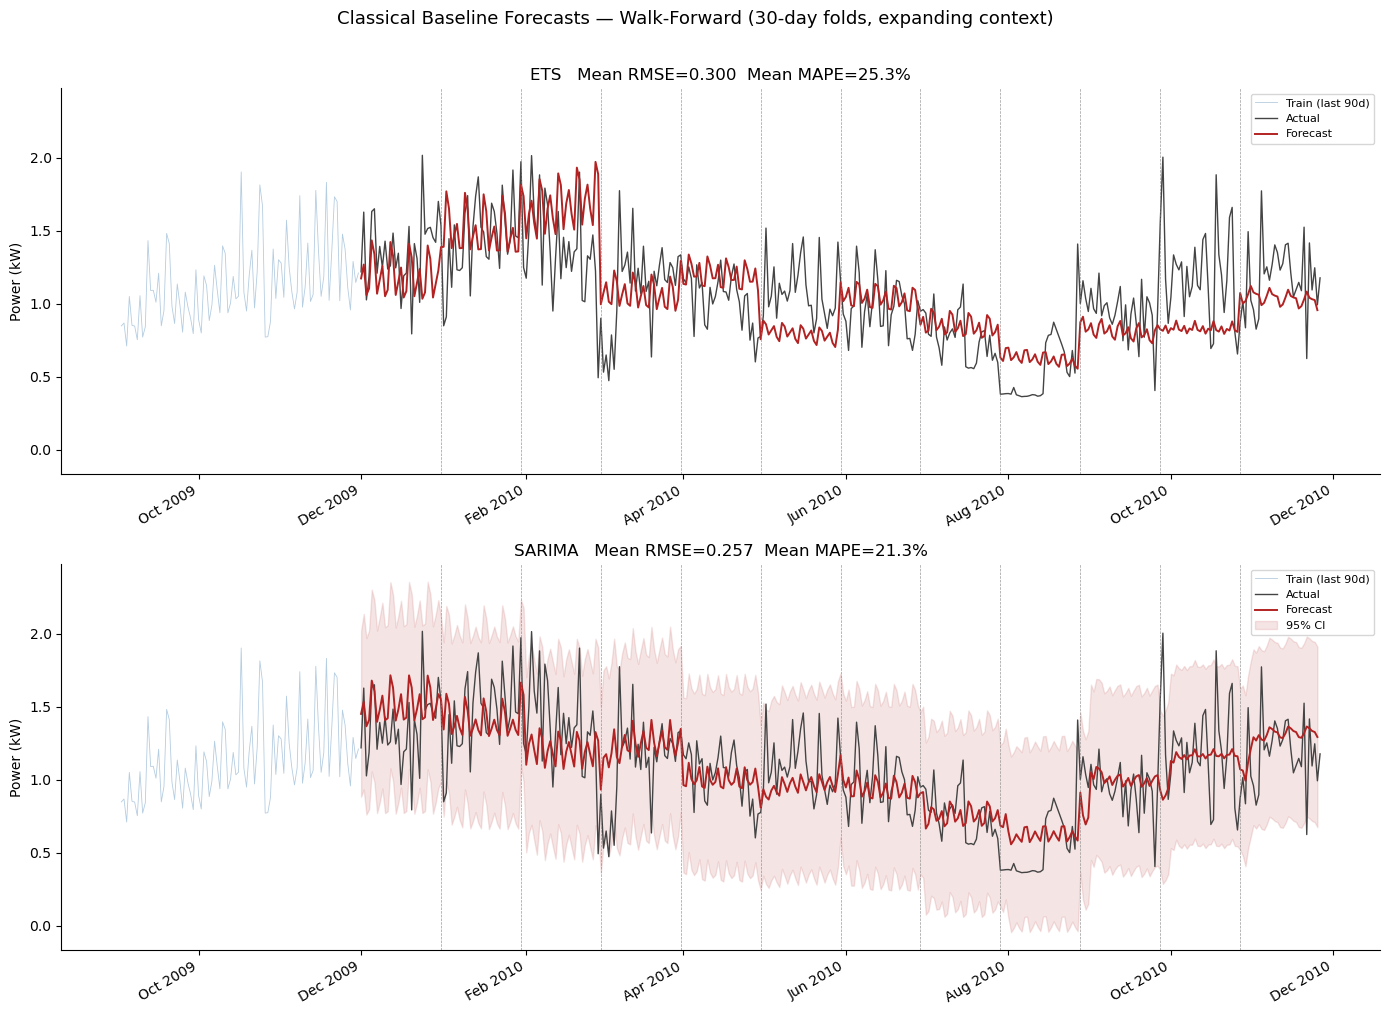

Saved → ../outputs/classical_forecasts.png


In [13]:
fig, axes = plt.subplots(2, 1, figsize=(14, 10), sharey=True)

for ax, (label, forecast) in zip(axes, [('ETS', ets_forecast), ('SARIMA', sarima_forecast)]):
    ax.plot(train_series.iloc[-90:], color='steelblue', linewidth=0.6, alpha=0.4, label='Train (last 90d)')
    ax.plot(test_series,             color='#444444',   linewidth=1.0, label='Actual')
    ax.plot(forecast,                color='firebrick', linewidth=1.4, label='Forecast')

    if label == 'SARIMA':
        ax.fill_between(
            conf_int_df.index,
            conf_int_df['lower'],
            conf_int_df['upper'],
            color='firebrick', alpha=0.12, label='95% CI'
        )

    for s in fold_starts[1:]:
        ax.axvline(x=test_series.index[s], color='gray', linestyle='--', linewidth=0.5, alpha=0.8)

    rmse_val = metrics.loc[label, 'RMSE']
    mape_val = metrics.loc[label, 'MAPE']
    ax.set_title(f'{label}   Mean RMSE={rmse_val:.3f}  Mean MAPE={mape_val:.1f}%')
    ax.set_ylabel('Power (kW)')
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
    plt.setp(ax.get_xticklabels(), rotation=30, ha='right')
    ax.legend(fontsize=8)
    sns.despine(ax=ax)

plt.suptitle('Classical Baseline Forecasts — Walk-Forward (30-day folds, expanding context)', y=1.01, fontsize=13)
plt.tight_layout()
plt.savefig('../outputs/classical_forecasts.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved → ../outputs/classical_forecasts.png")